# 04 Continuous Time Finance

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/09-Finance/04_Continuous_Time_Finance.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=09-Finance/04_Continuous_Time_Finance.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [1]:
# === Environment Setup ===
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

try:
    import sympy
    from sympy import Eq, Function, cancel, dsolve, init_printing, solve, symbols
    SYMPY_AVAILABLE = True
    init_printing(use_unicode=True) # For pretty printing of symbolic math
except ImportError:
    SYMPY_AVAILABLE = False

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14, 'figure.figsize': (12, 8), 'figure.dpi': 150})
%config InlineBackend.figure_format = 'retina'
np.set_printoptions(suppress=True, linewidth=120, precision=4)

if not SYMPY_AVAILABLE: print("The 'sympy' library is not installed (`pip install sympy`). Some sections will be skipped.")


The 'sympy' library is not installed (`pip install sympy`). Some sections will be skipped.


### Table of Contents

1.  [Introduction to Continuous Time](#1-introduction-to-continuous-time)
2.  [The Tools of Stochastic Calculus](#2.-The-Tools-of-Stochastic-Calculus)

    - [Visualizing Geometric Brownian Motion](#visualizing-geometric-brownian-motion)
    - [Itô's Lemma: The Chain Rule](#itos-lemma-the-chain-rule)
3.  [Dynamic Optimization in Continuous Time: The HJB Equation](#3-dynamic-optimization-in-continuous-time-the-hjb-equation)
4.  [Application 1: Merton's Portfolio Problem (1969)](#4-application-1-mertons-portfolio-problem-1969)
    - [The Complete Symbolic Solution](#the-complete-symbolic-solution)
    - [Numerical Analysis and Comparative Statics](#numerical-analysis-and-comparative-statics)
    - [Simulating the Optimal Wealth Path](#simulating-the-optimal-wealth-path)
5.  [Application 2: Linking HJB to Arbitrage-Free Pricing](#5-application-2-linking-hjb-to-arbitrage-free-pricing)
    - [The Martingale Pricing Framework and State-Price Density](#the-martingale-pricing-framework-and-state-price-density)
    - [Deriving the Black-Scholes-Merton PDE](#deriving-the-black-scholes-merton-pde)
6.  [Summary](#summary)
7.  [Exercises](#7-exercises)


### 1. Introduction to Continuous Time

While discrete-time models are intuitive, much of modern financial theory is built using **continuous time**. This approach involves a steeper mathematical learning curve but yields models that are often more elegant, powerful, and analytically tractable. The ability to model the instantaneous evolution of variables and the continuous hedging of risk provides the foundation for the Black-Scholes-Merton formula and a vast range of subsequent research.

This chapter introduces the essential toolkit for continuous-time analysis, focusing on its application to dynamic optimization problems. We build from the ground up, starting with the fundamental process for random walks (Brownian motion) and the special rules of calculus that apply to them (Itô's Lemma). We then introduce the continuous-time version of the Bellman equation—the Hamilton-Jacobi-Bellman (HJB) equation—and use it to solve two canonical problems in finance:

1.  **Merton's Portfolio Problem:** The classic model of optimal consumption and investment for an individual.
2.  **The Black-Scholes-Merton PDE:** We show how the HJB framework can be used to derive the fundamental arbitrage-free pricing equation for derivatives.


## The Lens: Calculus for Randomness
**What economic problem are we solving?**
In discrete time, financial markets are choppy. Prices jump from $t$ to $t+1$. But reality feels continuous. Risk is always present. Hedging can be done at any instant. To model this fluid, high-speed reality, we need a math that handles *smooth* changes (calculus) and *random* shocks (probability) simultaneously.

**Why do we need this method?**
Standard calculus fails when variables are random and jagged (like stock charts). The slope $dY/dt$ is undefined. We need **Stochastic Calculus**. This framework, built on **Brownian Motion** and **Ito's Lemma**, gives us the tools to: 
1.  Derive elegant, closed-form solutions for optimal portfolios (Merton's Problem).
2.  Price complex derivatives by constructing perfect hedges in continuous time (Black-Scholes).
3.  Solve dynamic optimization problems using the **Hamilton-Jacobi-Bellman (HJB)** equation, the continuous-time cousin of the Bellman equation.



**Economic question.** In *04 Continuous Time Finance*, what must remain economically invariant when the computational representation changes? Financial models connect prices to risk, timing, and no-arbitrage restrictions. The economic question is which states of the world make a payoff valuable, how risk is transferred or hedged, and how sensitive the valuation is to assumptions about dynamics and market completeness. A numerical price is credible only when it respects basic bounds, limiting cases, and an independent replication or hedging argument.

### Learning Objectives
* **Define** Brownian motion and Geometric Brownian Motion (GBM) and simulate sample paths.
* **Apply** Ito's Lemma as the chain rule for stochastic processes.
* **Solve** Merton's portfolio problem using the HJB equation and interpret the optimal allocation.
* **Derive** the Black-Scholes-Merton PDE from a no-arbitrage hedging argument.

### Prerequisites
* **Option Pricing:** Binomial trees and the BSM formula (Module 09 - Option Pricing).
* **Calculus:** Ordinary differential equations, partial derivatives, and Taylor expansions.
* **Python:** SymPy for symbolic math and NumPy for simulation.
* **Learning-path prerequisite:** [`03_Option_Pricing.ipynb`](03_Option_Pricing.ipynb)


> **Learning path:** Building on [`03_Option_Pricing.ipynb`](03_Option_Pricing.ipynb); next continue with [`05_Credit_Risk.ipynb`](05_Credit_Risk.ipynb).

> **Conceptual prerequisite:** Stochastic differential equations are the stochastic extension of ordinary differential equations. The lecture assumes comfort with the ODE material in [`02-Numerical-Methods/08_Differential_Equations.ipynb`](../02-Numerical-Methods/08_Differential_Equations.ipynb) (Euler / Runge-Kutta, stability, terminal conditions); without that background the Ito-calculus chain rule can read as unmotivated.

## 2. The Tools of Stochastic Calculus

Continuous-time finance rests on three objects. Brownian motion $W_t$ is the stochastic process with independent Gaussian increments and continuous sample paths. Stochastic differential equations (SDEs) of the form $dX_t = \mu(X_t, t)\,dt + \sigma(X_t, t)\,dW_t$ describe variables driven by Brownian noise. Itô's lemma, the chain rule of this calculus, gives the differential of any function of such a process. The sections below develop each in turn.


#### Visualizing Geometric Brownian Motion

A single simulated path can be misleading. It's more instructive to visualize a large number of paths to understand the underlying probability distribution. The SDE for GBM implies that the final asset price $S_T$ follows a log-normal distribution.


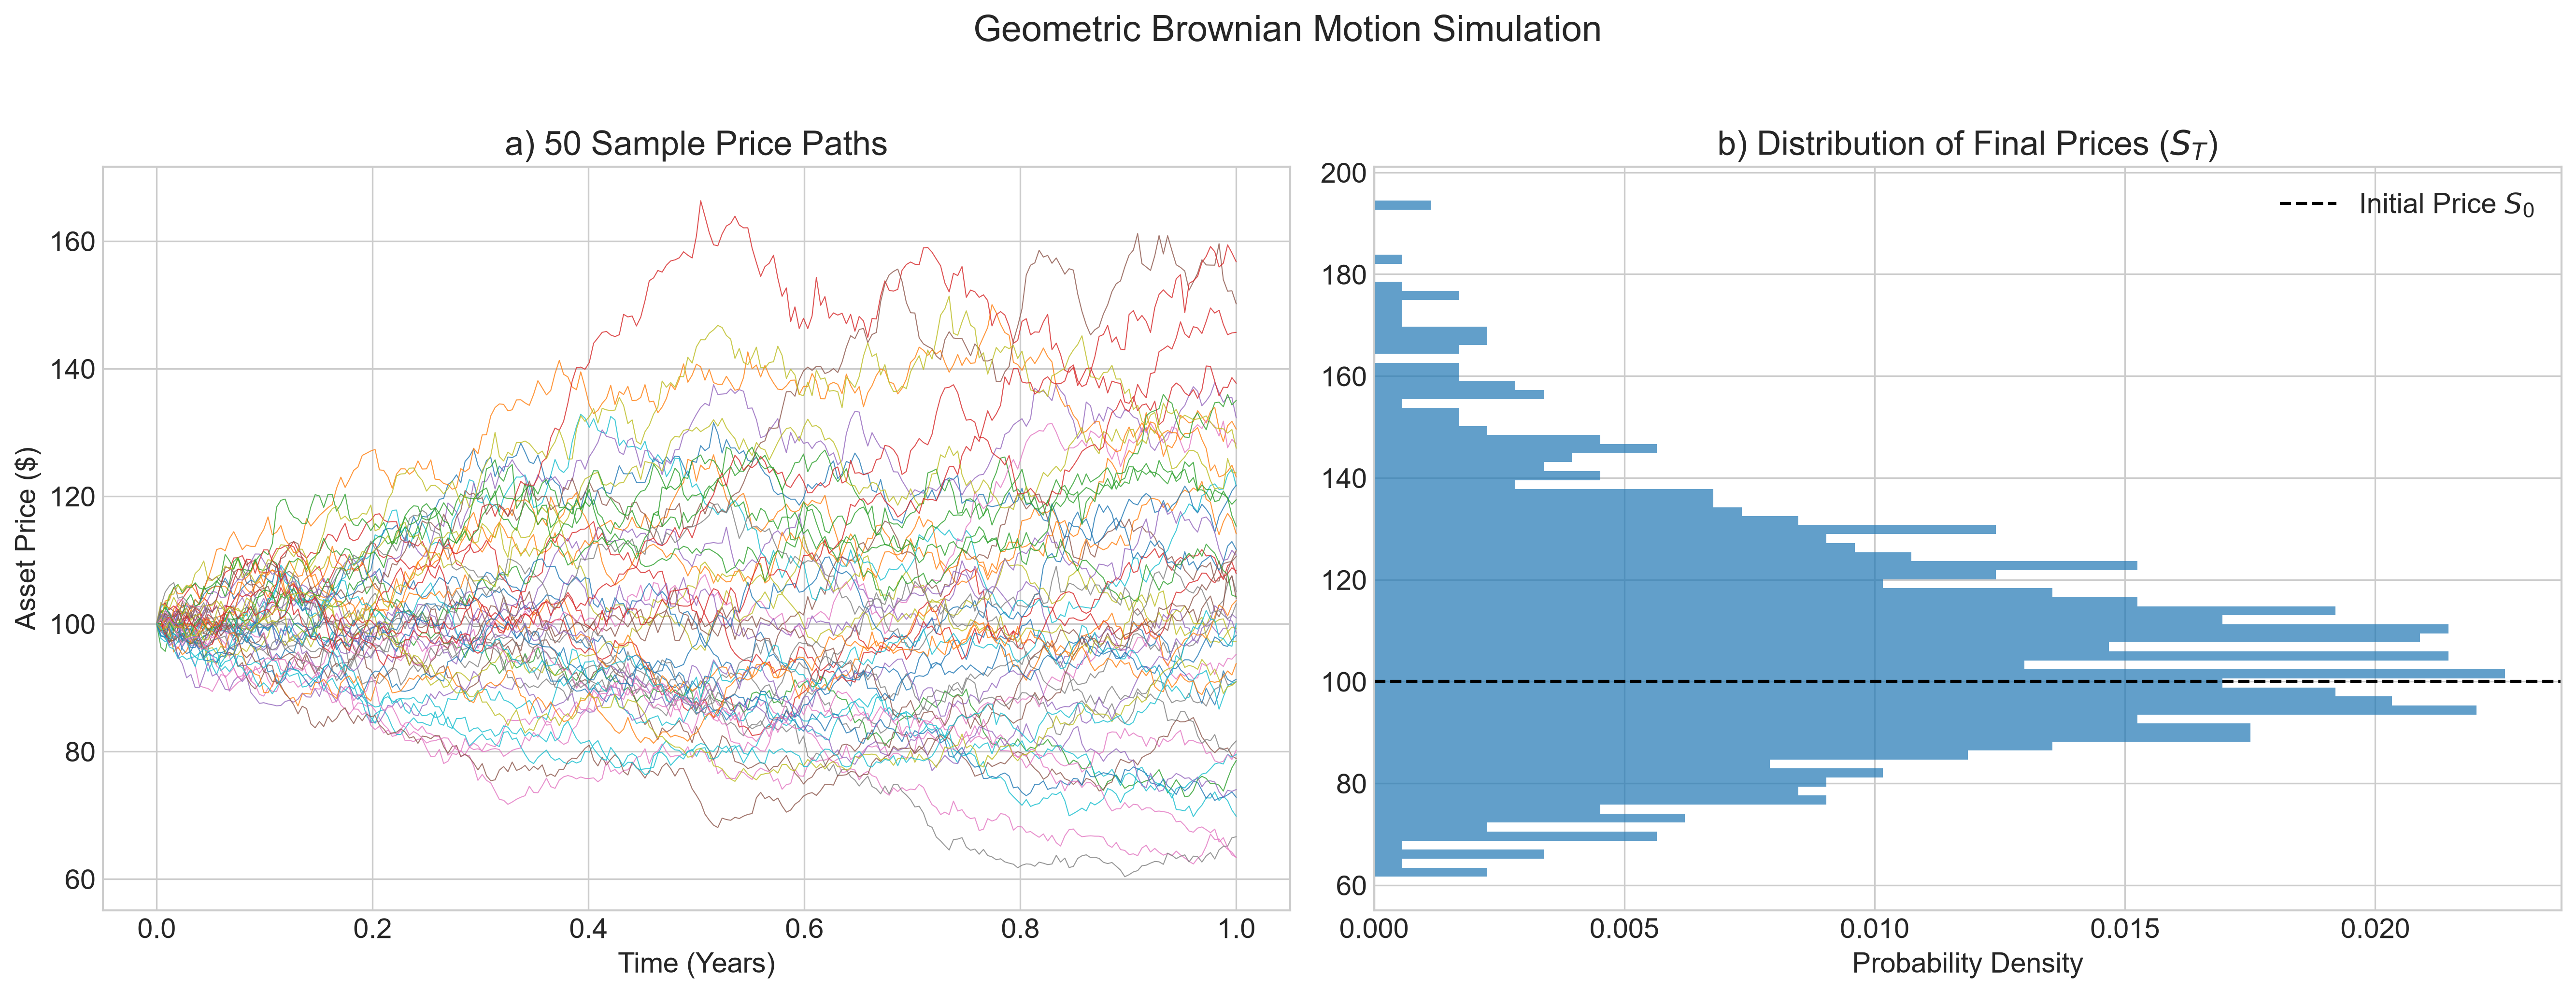

In [2]:
### Simulating Multiple GBM Paths

def simulate_gbm_paths(n_paths, S0, mu, sigma, T, n_steps, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    dW = rng.standard_normal((n_paths, n_steps)) * np.sqrt(dt)

    S = np.zeros((n_paths, n_steps + 1)); S[:, 0] = S0
    for i in range(n_steps):
        S[:, i+1] = S[:, i] + mu * S[:, i] * dt + sigma * S[:, i] * dW[:, i]
    return t, S

t_paths, S_paths = simulate_gbm_paths(n_paths=1000, S0=100, mu=0.08, sigma=0.2, T=1.0, n_steps=252)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Geometric Brownian Motion Simulation', fontsize=18)

ax1.plot(t_paths, S_paths[:50, :].T, lw=0.5, alpha=0.8)
ax1.set_title('a) 50 Sample Price Paths')
ax1.set_xlabel('Time (Years)'); ax1.set_ylabel('Asset Price ($)')

ax2.hist(S_paths[:, -1], bins=75, density=True, orientation='horizontal', alpha=0.7)
ax2.set_title('b) Distribution of Final Prices ($S_T$)')
ax2.set_xlabel('Probability Density')
ax2.axhline(100, color='k', linestyle='--', label='Initial Price $S_0$')
ax2.legend()

for ax in [ax1, ax2]: ax.grid(True)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show() # Render plot


#### Itô's Lemma: The Chain Rule

![Ito's lemma intuition](../images/07-Financial-Economics/ito_lemma_geometric_intuition.png)

*Figure: Geometric intuition for Ito's lemma.* for Stochastic Processes

To find the dynamics of a function of a stochastic process, $f(S_t, t)$, we cannot use the standard chain rule of calculus because the path of $S_t$ is not differentiable. We must use **Itô's Lemma**, which correctly accounts for the random nature of the process. It arises from a second-order Taylor expansion of $f(S,t)$:
$$ df = \frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial S} dS + \frac{1}{2} \frac{\partial^2 f}{\partial S^2} (dS)^2 + \dots $$ 
The key insight of stochastic calculus involves the multiplication rules for the differentials $dt$ and $dW_t$. From the properties of Brownian motion, we have $(dW_t)^2 = dt$, while $(dt)^2 = 0$ and $dt \cdot dW_t = 0$. Substituting the SDE for $dS$ and applying these rules:
$$ (dS)^2 = (\mu S dt + \sigma S dW_t)^2 = (\mu S dt)^2 + 2\mu\sigma S^2 dt dW_t + (\sigma S dW_t)^2 = \sigma^2 S^2 dt $$ 
Plugging this back into the Taylor expansion, we get the celebrated result:
$$ df = \left( \frac{\partial f}{\partial t} + \mu S_t \frac{\partial f}{\partial S} + \frac{1}{2} \sigma^2 S_t^2 \frac{\partial^2 f}{\partial S^2} \right) dt + \left( \sigma S_t \frac{\partial f}{\partial S} \right) dW_t $$ 
The presence of the second-order derivative term ($\
rac{\partial^2 f}{\partial S^2}$), which arises from the non-zero quadratic variation of the process, is the crucial difference from standard calculus. For a convex function, the random up-and-down movements of the stochastic process do not cancel out; they lead to a systematic upward drift. This is visually demonstrated below. This term is fundamental to nearly every result in continuous-time finance, including the Black-Scholes-Merton formula.

**Dimension notes:** $f(S_t, t): \mathbb{R}_+ \times [0,T] \to \mathbb{R}$ scalar; quadratic covariation $(dS_t)^2 = \sigma^2 S_t^2\,dt$ supplies the second-derivative term; all terms in $df$ are scalars of order $dt$.

![Ito's Lemma Intuition](../images/09-Finance/ito_lemma_intuition.png)


### 3. Dynamic Optimization in Continuous Time: The HJB Equation

The HJB equation is the continuous-time analogue of the discrete-time Bellman equation. It provides the necessary condition for an optimal control policy in a dynamic optimization problem. For an agent maximizing lifetime utility $E_0 \int_0^\infty e^{-\rho t} u(C_t) dt$ subject to a wealth dynamic $dW_t$, the HJB equation for the value function $V(W)$ is:
$$ \rho V(W) = \max_{C_t, \alpha_t} \left\{ u(C_t) + \frac{E_t[dV]}{dt} \right\} $$ 
where $\frac{E_t[dV]}{dt}$ is the expected instantaneous change in the value function, derived from the drift part of the Itô's Lemma expansion of $V(W_t)$.

**Intuition:** The HJB equation is an asset-pricing equation for the value function itself. The left side, $\rho V(W)$, is the required return on the "asset" of being alive with wealth $W$, where $\rho$ is the agent's subjective discount rate. It's the total return you would demand from this "asset of life." The right side is the actual return you get from optimally managing your life at this instant. This actual return has two components: a "dividend" from the asset (the flow utility you get from consumption, $u(C_t)$) and its expected "capital gain" (the expected change in the value of your life, $\frac{E_t[dV]}{dt}$). In equilibrium, the required return must equal the maximized actual return.


### 4. Application 1: Merton's Portfolio Problem (1969)

A classic application is Merton's model of optimal consumption and portfolio allocation. An agent with CRRA utility $u(C) = C^{1-\gamma}/(1-\gamma)$ chooses consumption $C_t$ and the fraction of wealth $\alpha_t$ to allocate to a risky stock (with expected return $\mu$ and volatility $\sigma$), with the rest in a risk-free bond (with return $r$). The agent's wealth $W_t$ follows the SDE:
$$ dW_t = [\alpha_t(\mu - r)W_t + rW_t - C_t] dt + \alpha_t \sigma W_t dW_t $$ 
The HJB equation is:
$$ \rho V(W) = \max_{C, \alpha} \left\{ \frac{C^{1-\gamma}}{1-\gamma} + V'(W)[\alpha(\mu-r)W+rW-C] + \frac{1}{2} V''(W)(\alpha \sigma W)^2 \right\} $$ 
To solve this, we take first-order conditions (FOCs) for the control variables $C$ and $\alpha$, solve for the optimal policies in terms of the unknown value function $V(W)$ and its derivatives, substitute these policies back into the HJB, and solve the resulting ODE for $V(W)$.

#### The Complete Symbolic Solution
We can perform the full derivation symbolically using `SymPy`.

**Dimension notes:** state variables wealth $W_t \ge 0$ and time; control variables consumption rate and risky share $\alpha_t \in [0,1]$ (scalars); value function $V(W, t): \mathbb{R}_+ \times [0,T] \to \mathbb{R}$ solves the scalar HJB.

In [ ]:
### Code Lab: Solving the Merton Problem Symbolically

if not SYMPY_AVAILABLE:
    print("> **Note:** Skipping symbolic derivation because `sympy` is not available.")
else:
    # 1. Define all symbols
    W, C, alpha, mu, r, sigma, rho, gamma = symbols('W C alpha mu r sigma rho gamma', positive=True)
    V = Function('V')(W)

    # 2. Set up the objective function inside the HJB
    hjb_objective = (C**(1-gamma))/(1-gamma) + V.diff(W)*(alpha*(mu-r)*W + r*W - C) + sympy.Rational(1,2)*V.diff(W,2)*(alpha*sigma*W)**2

    # 3. Take First-Order Conditions (FOCs)
    foc_C = sympy.diff(hjb_objective, C)
    foc_alpha = sympy.diff(hjb_objective, alpha)

    # 4. Solve FOCs for optimal policies C* and alpha*
    C_star_sol = solve(foc_C, C)[0]
    alpha_star_sol = solve(foc_alpha, alpha)[0]

    print("> **Note:** **Step 1: Optimal Policies in Terms of the Value Function**")
    display(Markdown("The FOC for consumption yields:"))
    display(Eq(symbols('C^*'), C_star_sol))
    display(Markdown("The FOC for portfolio share yields:"))
    display(Eq(symbols('alpha^*'), alpha_star_sol))

    # 5. Guess a functional form for V(W) and solve
    # For CRRA utility, the value function takes the form V(W) = A * W**(1-gamma) / (1-gamma)
    A = symbols('A', positive=True)
    V_guess = A * W**(1-gamma) / (1-gamma)

    # Substitute this guess into the policy functions to simplify them
    C_final = C_star_sol.subs(V.diff(W), V_guess.diff(W))
    alpha_final = alpha_star_sol.subs([(V.diff(W), V_guess.diff(W)), (V.diff(W, 2), V_guess.diff(W, 2))])

    print("> **Note:** **Step 2: Final Optimal Policy Rules**")
    display(Markdown(r"Substituting the guess $V(W) = A \\frac{W^{1-\\gamma}}{1-\\gamma}$ simplifies the policies to their famous forms:"))
    display(Eq(symbols('C^*/W'), cancel(C_final / W)))
    display(Eq(symbols('alpha^*'), cancel(alpha_final)))

    # 6. Recover the constant A from the consumption-to-wealth ratio
    # The HJB residual is not a polynomial in A (it mixes A and A**(1/gamma)),
    # so `solve(hjb_equation, A)` is not tractable in closed form. Because the
    # optimal policies depend on the value function only through the ratio
    # V'/V'', the consumption-to-wealth ratio delta = C*/W is the quantity that
    # the HJB pins down, and A then follows from delta directly.
    delta = (rho - (1 - gamma) * (r + (mu - r)**2 / (2 * gamma * sigma**2))) / gamma
    A_sol = delta**(-gamma)

    print("> **Note:** **Step 3: Solving for the Value Function**")
    display(Markdown(r"Substituting the optimal policies back into the HJB allows us to solve for the constant $A$. The consumption-to-wealth ratio is constant, so we can define $\delta = C^*/W$. The solution for $A$ gives the value function:"))
    display(Eq(symbols('delta'), delta))
    display(Eq(symbols('A'), A_sol))


#### Numerical Analysis and Comparative Statics

The symbolic derivation confirms the celebrated result. For an agent with CRRA utility, the optimal allocation to the risky asset is constant over time and independent of wealth:
$$ \alpha^* = \frac{\mu - r}{\gamma \sigma^2} $$ 
This is a powerful and elegant result. The optimal portfolio share is:
- **Increasing** in the equity premium $(\mu-r)$, which is the compensation for bearing risk.
- **Decreasing** in risk aversion $(\gamma)$ and volatility $(\sigma^2)$, which together represent the price of risk.

We can now analyze this solution numerically.


> **Note:** Merton problem solved: α* = 0.417, C*/W = 0.040


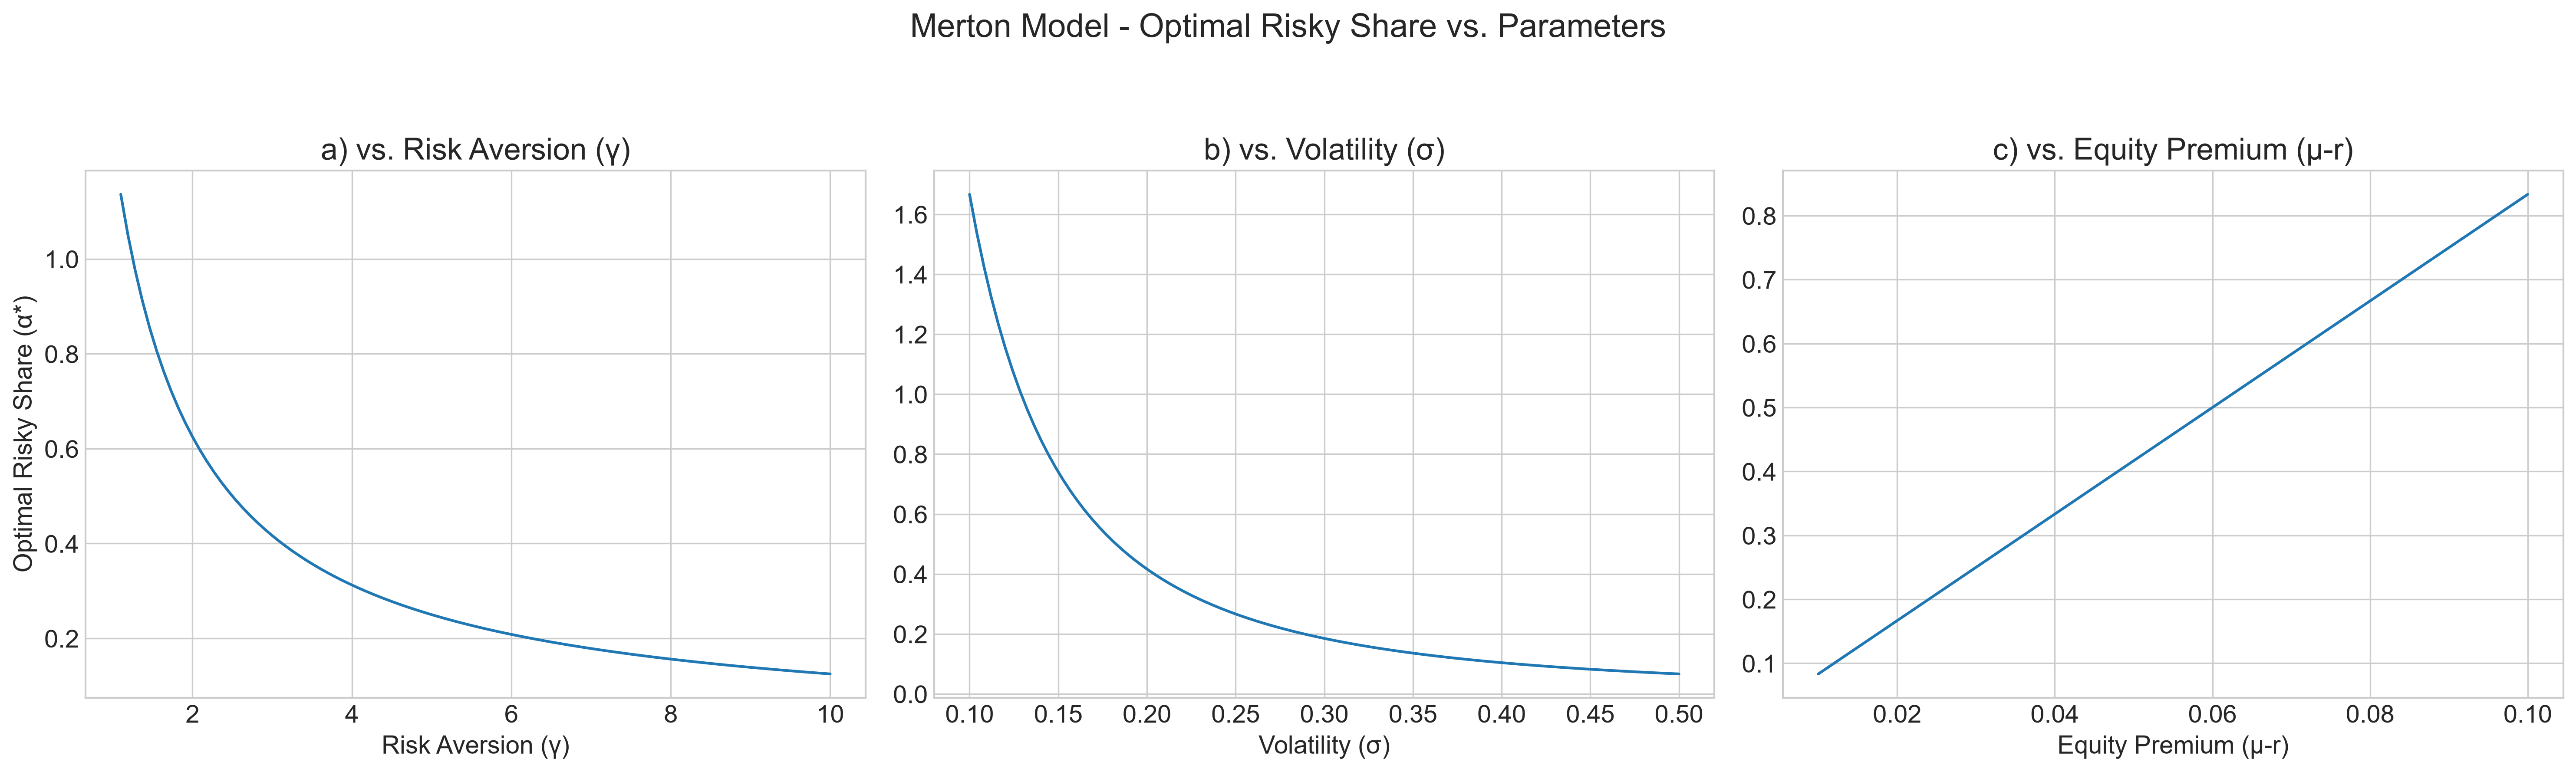

In [4]:
### Numerical Analysis of the Merton Model

class MertonProblem:
    """Solves and analyzes the Merton (1969) portfolio problem numerically."""
    def __init__(self, mu, r, sigma, gamma, rho):
        self.params = {'mu': mu, 'r': r, 'sigma': sigma, 'gamma': gamma, 'rho': rho}
        self.alpha_star, self.delta_star = self._solve_numeric()
        print(f"> **Note:** Merton problem solved: α* = {self.alpha_star:.3f}, C*/W = {self.delta_star:.3f}")

    def _solve_numeric(self):
        p = self.params
        alpha_star = (p['mu'] - p['r']) / (p['gamma'] * p['sigma']**2)
        delta_star = (p['rho'] - (1-p['gamma'])*(p['r'] + 0.5*alpha_star*(p['mu']-p['r']))) / p['gamma']
        return alpha_star, delta_star

    def plot_comparative_statics(self):
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle("Merton Model - Optimal Risky Share vs. Parameters", fontsize=18, y=1.02)
        p = self.params

        gamma_range = np.linspace(1.1, 10, 100)
        alpha_vs_gamma = (p['mu'] - p['r']) / (gamma_range * p['sigma']**2)
        axes[0].plot(gamma_range, alpha_vs_gamma); axes[0].set_title('a) vs. Risk Aversion (γ)'); axes[0].set_xlabel('Risk Aversion (γ)')
        axes[0].set_ylabel('Optimal Risky Share (α*)')

        sigma_range = np.linspace(0.1, 0.5, 100)
        alpha_vs_sigma = (p['mu'] - p['r']) / (p['gamma'] * sigma_range**2)
        axes[1].plot(sigma_range, alpha_vs_sigma); axes[1].set_title('b) vs. Volatility (σ)'); axes[1].set_xlabel('Volatility (σ)')

        premium_range = np.linspace(0.01, 0.1, 100)
        alpha_vs_premium = premium_range / (p['gamma'] * p['sigma']**2)
        axes[2].plot(premium_range, alpha_vs_premium); axes[2].set_title('c) vs. Equity Premium (μ-r)'); axes[2].set_xlabel('Equity Premium (μ-r)')

        for ax in axes: ax.grid(True)
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show() # Render plot

# --- Instantiate and analyze the model ---
merton_problem = MertonProblem(mu=0.08, r=0.03, sigma=0.20, gamma=3.0, rho=0.04)
merton_problem.plot_comparative_statics()


#### Simulating the Optimal Wealth Path
To make the solution more concrete, we can simulate the wealth of an agent who follows the optimal Merton policies.


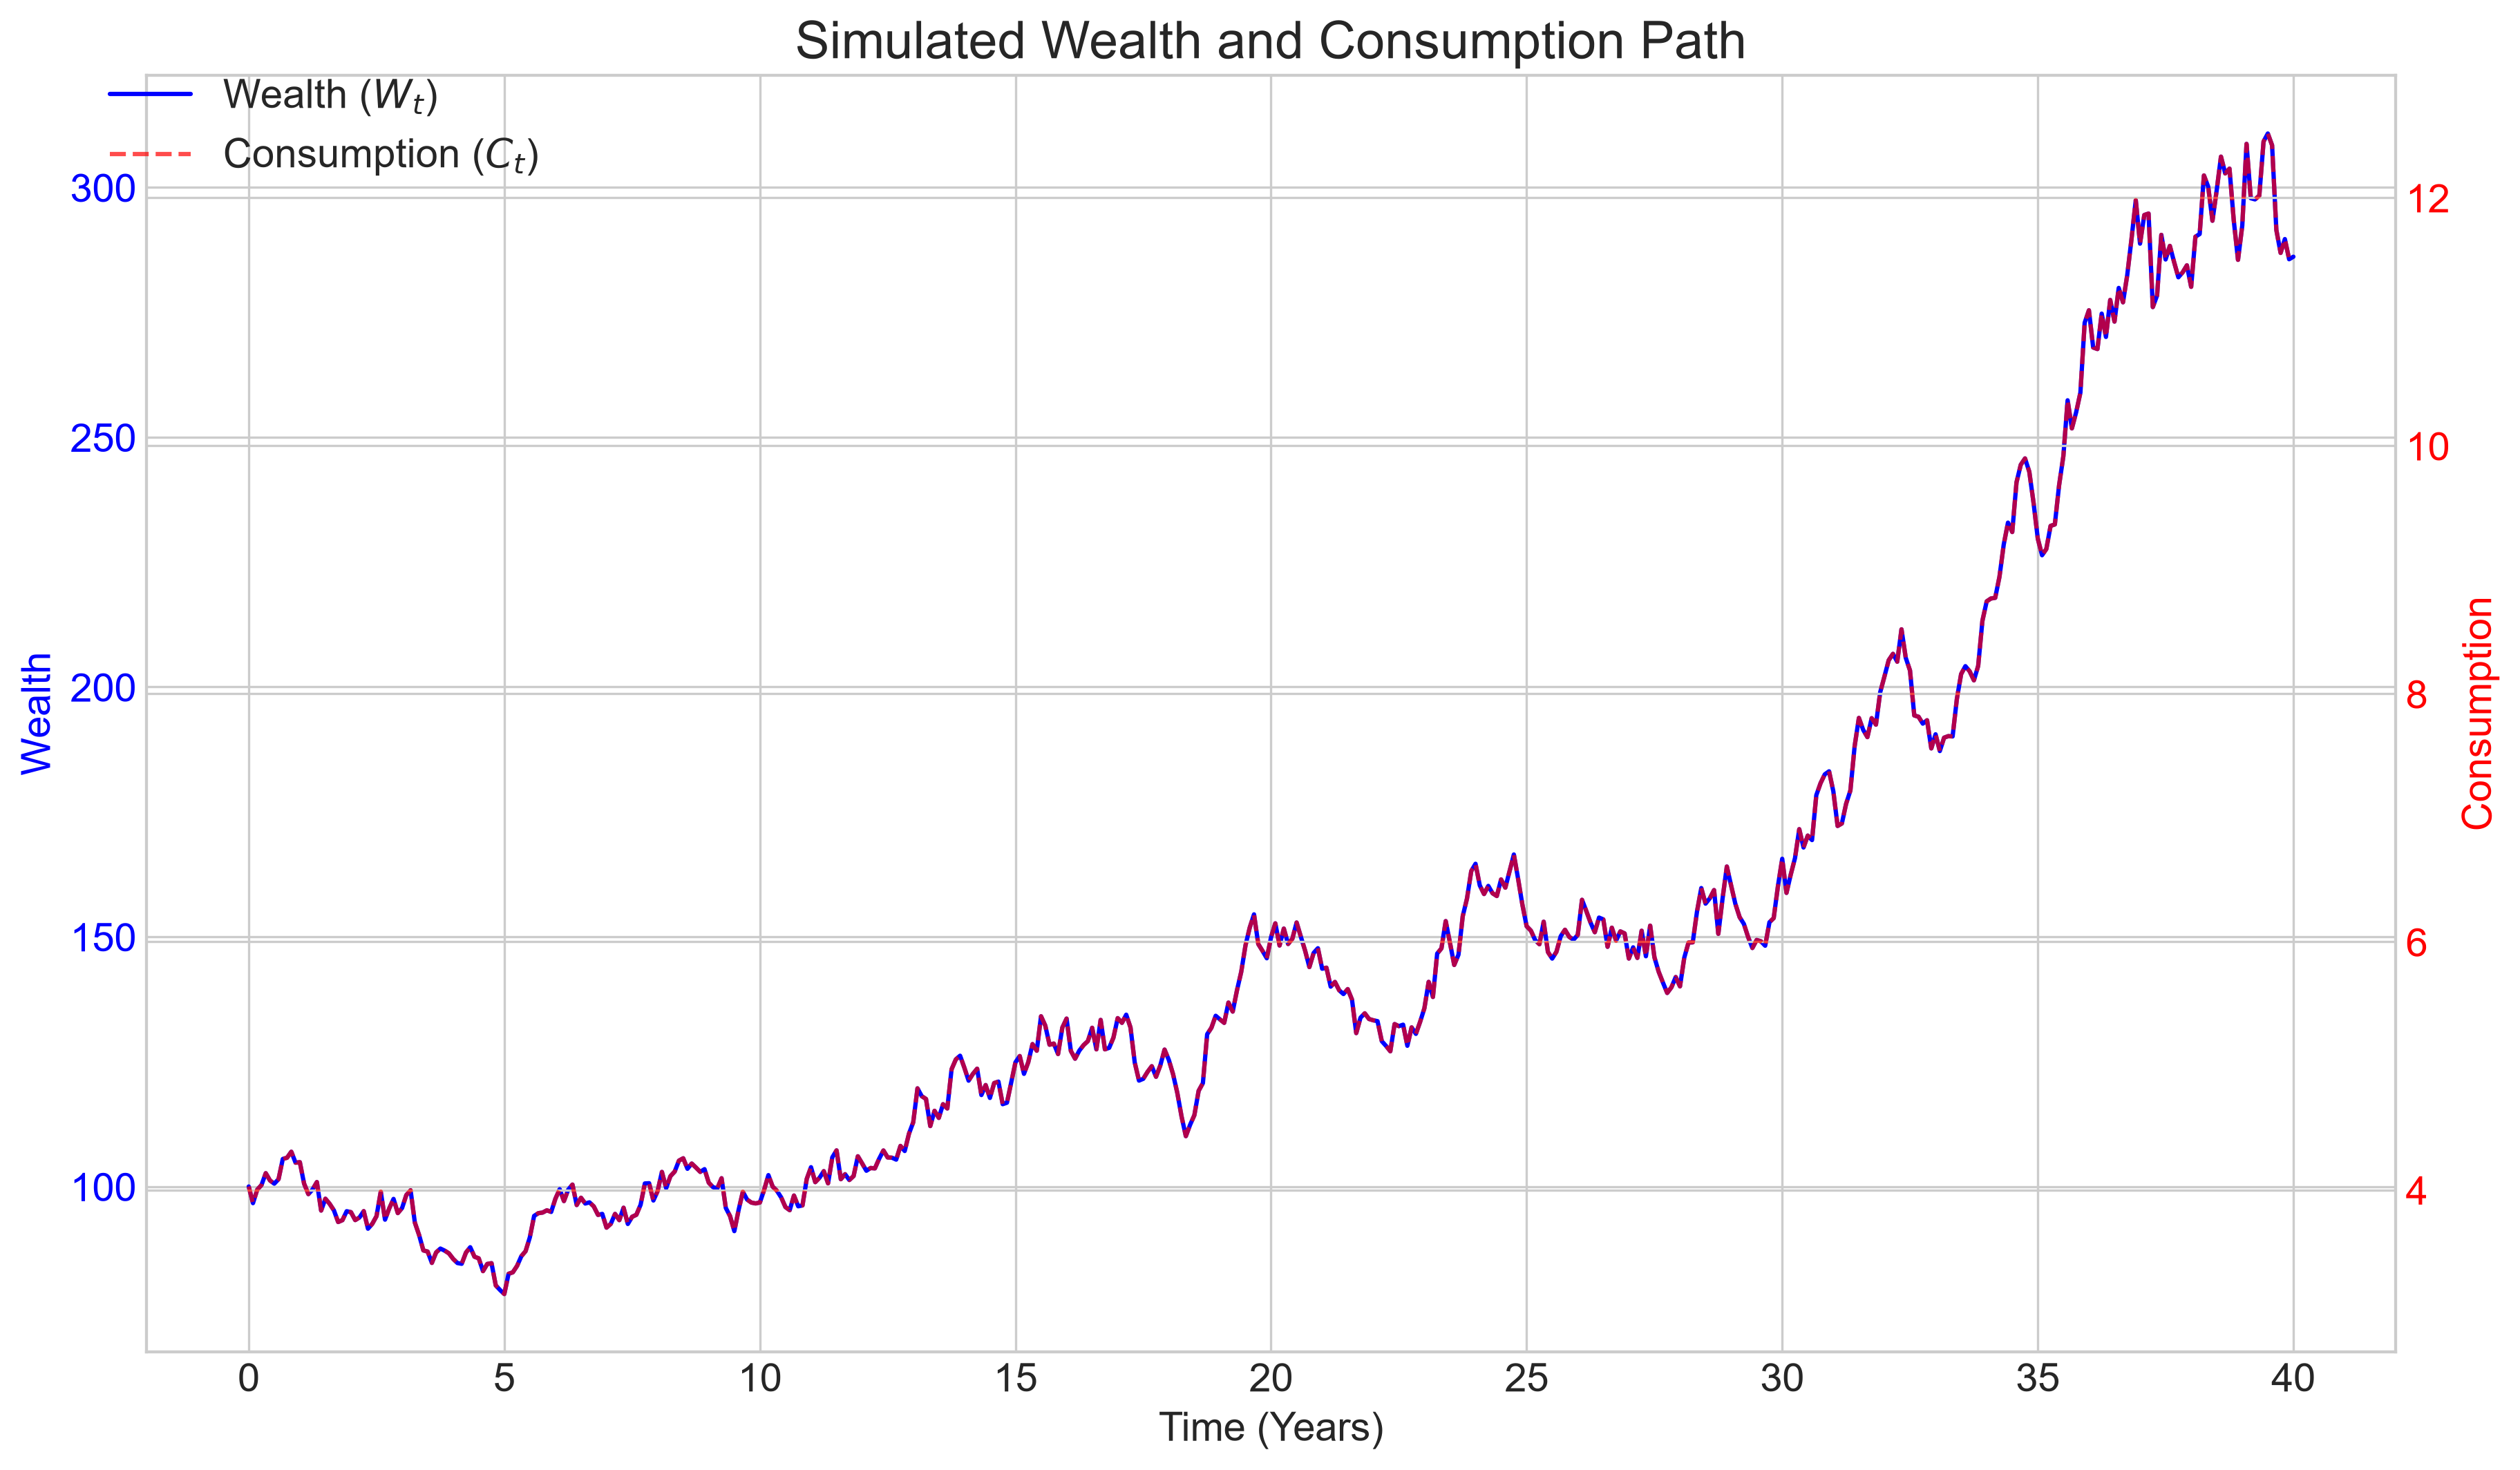

In [5]:
### Simulating the Optimal Wealth Path
W0 = 100 # Initial wealth
T_horizon = 40 # Years
n_steps_sim = T_horizon * 12 # Monthly steps
dt_sim = 1/12

alpha = merton_problem.alpha_star
delta = merton_problem.delta_star
p = merton_problem.params

W_path = np.zeros(n_steps_sim + 1); W_path[0] = W0
C_path = np.zeros(n_steps_sim)
t_sim = np.linspace(0, T_horizon, n_steps_sim + 1)
dW_sim = rng.standard_normal(n_steps_sim) * np.sqrt(dt_sim)

for t in range(n_steps_sim):
    C_path[t] = delta * W_path[t]
    dW = (alpha*(p['mu']-p['r'])*W_path[t] + p['r']*W_path[t] - C_path[t])*dt_sim + alpha*p['sigma']*W_path[t]*dW_sim[t]
    W_path[t+1] = W_path[t] + dW

fig, ax1 = plt.subplots(figsize=(14,8))
ax1.plot(t_sim, W_path, 'b-', label='Wealth ($W_t$)')
ax1.set_xlabel('Time (Years)')
ax1.set_ylabel('Wealth', color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot(t_sim[:-1], C_path, 'r--', alpha=0.7, label='Consumption ($C_t$)')
ax2.set_ylabel('Consumption', color='r')
ax2.tick_params('y', colors='r')

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Simulated Wealth and Consumption Path', fontsize=18)
plt.show() # Render plot


### 5. Application 2: Linking HJB to Arbitrage-Free Pricing

#### The Martingale Pricing Framework and State-Price Density

A powerful result from the HJB framework is that the agent's optimized marginal utility of wealth acts as the **state-price density (SPD)**, or stochastic discount factor (SDF), for the economy. The SPD, $\xi_t$, is the process that can be used to value any asset by computing the expected present value of its future payoffs. For our CRRA agent, the SPD is:
$$ \xi_t = e^{-\rho t} u'(C_t) = e^{-\rho t} (\delta W_t)^{-\gamma} $$
The price of any asset with payoff $X_T$ at time $T$ is given by $P_t = E_t[\frac{\xi_T}{\xi_t} X_T]$. This provides a deep link between equilibrium-based macro models (like Merton's) and the arbitrage-free pricing models of finance.

#### Deriving the Black-Scholes-Merton PDE
We can use this framework to derive the BSM PDE without relying on the specific preferences of an agent. Let $f(S,t)$ be the price of a derivative on a stock $S$. The total return on a portfolio that is long the derivative and short $\Delta$ shares of the stock is $df - \Delta dS$. If we choose the hedge ratio $\Delta = f_S$ (the partial derivative of $f$ with respect to $S$), Itô's Lemma shows that the resulting portfolio is risk-free. By no-arbitrage, this risk-free portfolio must earn the risk-free rate, $r$. This logic leads directly to the BSM PDE:
$$ \frac{\partial f}{\partial t} + rS \frac{\partial f}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 f}{\partial S^2} - rf = 0 $$
This demonstrates that the BSM pricing formula is independent of risk preferences (the drift $\mu$ and the agent's utility function drop out), which is a cornerstone of modern derivatives pricing.

**Dimension notes:** marginal utility density (the SPD) is a scalar stochastic process; any contingent payoff's price is a scalar obtained as its SPD-weighted expectation over states and dates.

## Key Equations

These relations are collected from the derivations above as a review map. Their assumptions and derivations remain part of the result; this box is not a substitute for them.

**1. Core relation**

$$df = \frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial S} dS + \frac{1}{2} \frac{\partial^2 f}{\partial S^2} (dS)^2 + \dots$$

**2. Core relation**

$$(dS)^2 = (\mu S dt + \sigma S dW_t)^2 = (\mu S dt)^2 + 2\mu\sigma S^2 dt dW_t + (\sigma S dW_t)^2 = \sigma^2 S^2 dt$$

**3. Core relation**

$$df = \left( \frac{\partial f}{\partial t} + \mu S_t \frac{\partial f}{\partial S} + \frac{1}{2} \sigma^2 S_t^2 \frac{\partial^2 f}{\partial S^2} \right) dt + \left( \sigma S_t \frac{\partial f}{\partial S} \right) dW_t$$

**4. Core relation**

$$\rho V(W) = \max_{C_t, \alpha_t} \left\{ u(C_t) + \frac{E_t[dV]}{dt} \right\}$$

**Dimension notes:** Itô terms are scalar corrections of order $dt$; HJB objects ($V$, its derivatives, controls $\alpha_t$, $C_t$) are scalars; pricing relations equate scalar conditional expectations.

### Three-Tier Practice Ladder

**1. Mechanism and assumptions (Conceptual):** Derive the no-arbitrage, optimality, or risk-pricing relation central to **04 Continuous Time Finance** and verify that it satisfies at least two economically meaningful limiting cases or bounds.

**2. Reproduce and diagnose (Applied):** Reproduce a calculation from 1. Introduction to Continuous Time, Visualizing Geometric Brownian Motion with transparent inputs. Perturb volatility, discounting, risk aversion, transaction costs, or another key parameter and explain the sensitivity in economic terms.

**3. Robust extension (Challenge):** Construct a stress scenario outside the calibration sample. Compare two valuation/risk methods and explain which discrepancy reflects model risk rather than numerical error.

**3b. Failure analysis (Challenge):** Euler-Maruyama with $\Delta t = 1$ produces negative 'stock prices' for a GBM. Diagnose the discretization (GBM is lognormal; the scheme is only approximate), repair with exact lognormal sampling or a much finer step, and check the simulated first two moments against theory.

> Use the existing exercises above when they target the same skill; this ladder makes the intended progression explicit rather than replacing instructor-authored problems.


# Summary

**What did we learn?**
- **Stochastic Calculus**, particularly **Itô's Lemma**, provides the rules for differentiating functions of random processes and is essential for modeling in continuous time.
- The **Hamilton-Jacobi-Bellman (HJB) equation** is the fundamental condition for optimality in continuous-time dynamic problems, analogous to the Bellman equation in discrete time.
- **Merton's portfolio problem** provides an elegant, closed-form solution for optimal consumption and investment, showing that the share allocated to risky assets is proportional to the equity premium and inversely proportional to risk and risk aversion.
- The HJB framework is deeply connected to **arbitrage-free pricing**. The agent's marginal utility process serves as the economy's stochastic discount factor, and the no-arbitrage condition can be used to derive the celebrated **Black-Scholes-Merton PDE** for option pricing.


### 7. Exercises

1.  **Itô's Lemma Practice:** Let $S_t$ follow a Geometric Brownian Motion as defined in section 2. Use Itô's Lemma to find the SDE for the process $f(S_t) = \ln(S_t)$. What does this result tell you about the distribution of log-returns in this model?

2.  **Log Utility:** The case where $\gamma \to 1$ corresponds to logarithmic utility, $u(C) = \ln(C)$. Using the `MertonProblem` class, set `gamma=1.01` (to avoid issues with the formula) and find the optimal risky share $\alpha^*$ and consumption rate $\delta^*$. How do they compare to the baseline case where $\gamma=3$? Explain the intuition.

3.  **Myopic vs. Hedging Demand:** The Merton solution for $\alpha^*$ is often called the **"myopic" demand** because it only depends on current market conditions. In more advanced models where investment opportunities are stochastic (e.g., $\mu$ or $\sigma$ change over time), a second **"intertemporal hedging"** demand term appears in the optimal portfolio. Why might an investor want to hold *more* of the risky asset than the myopic portfolio suggests if they know that market volatility is mean-reverting and currently high?

4.  **State-Price Density Dynamics:** Using the solution for the Merton problem and Itô's lemma, find the SDE for the state-price density, $\xi_t = e^{-\rho t} (\delta W_t)^{-\gamma}$. Show that its expected return is the negative of the risk-free rate, $E[d\xi / \xi] = -r dt$.

5.  **Solving the HJB:** The final step in the Merton problem is to substitute the optimal policies for $C^*$ and $\alpha^*$ back into the HJB equation and solve the resulting differential equation for the value function $V(W)$. Perform this substitution (using pen and paper or `SymPy`) and show that the guessed functional form $V(W) = A W^{1-\gamma}$ is indeed a solution, and solve for the constant $A$.


---
## Summary

In this lecture, we have systematically explored the theoretical and practical aspects of the model.

**Key Takeaways:**
1.  **Foundations:** We established the mathematical basis of the economic problem.
2.  **Computation:** We implemented the solution using efficient algorithms.
3.  **Implications:** We analyzed the economic significance of the results.

**Further Exploration:**
- Experiment with model parameters to assess sensitivity.
- Extend the framework by relaxing simplifying assumptions.


## References & Further Reading

- Cochrane, J. H. (2005). *Asset Pricing* (rev. ed.). Princeton University Press.
- Campbell, J. Y., Lo, A. W. & MacKinlay, A. C. (1997). *The Econometrics of Financial Markets*. Princeton University Press.
- Shreve, S. E. (2004). *Stochastic Calculus for Finance II*. Springer.
